<a href="https://colab.research.google.com/github/project-ida/arpa-e-experiments/blob/main/2024-08-29-palladium-foil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; <a href="https://nbviewer.jupyter.org/github/project-ida/arpa-e-experiments/blob/main/2024-08-29-palladium-foil.ipynb" target="_parent"><img src="https://nbviewer.jupyter.org/static/img/nav_logo.svg" alt="Open In nbviewer" width="100"/></a>

# 2024-08-29 Palladium foil

A xy mg Palladium foil is gas loaded with deuterium, in a 0.19L chamber.

In [ ]:
# RUN THIS IF YOU ARE USING GOOGLE COLAB
import sys
import os
!git clone https://github.com/project-ida/arpa-e-experiments.git
sys.path.insert(0,'/content/arpa-e-experiments')
os.chdir('/content/arpa-e-experiments')

In [1]:
# Libraries and helper functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import Image
from IPython.display import Video
from IPython.display import HTML

# Use our custom helper functions
# - process_data
# - plot_panels
from libs.helpers import *

/Users/matt/anaconda3/envs/anaconda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# This will go into the title of all plots
experiment_descriptor = "Palladium foil"

## Reading the raw data

### Temperature

In [3]:
# Read the tempearture data
temperature_df = pd.read_csv(
    'http://nucleonics.mit.edu/call-rscript.php?filename=thermocouples_september&graphno=1f&random=85',
    parse_dates=['time'],
    date_format="ISO8601",
    index_col='time'
)

In [4]:
# When does data collection begin and end
print(f"Start: {temperature_df.index[0]}, End: {temperature_df.index[-1]}")

Start: 2024-08-29 15:30:00.717960, End: 2024-09-03 11:59:59.081898


In [5]:
# How many data points do we have
raw_total_temperature_points = len(temperature_df)
print(raw_total_temperature_points)

358299


In [6]:
# What's the average time in seconds time between data points
((temperature_df.index[-1] - temperature_df.index[0]) / raw_total_temperature_points).total_seconds()

1.170526

In [7]:
# Count problem values like NaNs
temperature_df.isna().sum()

Thermocouple1Ch1         0
Thermocouple1Ch2         1
Thermocouple1Ch3    100905
Thermocouple1Ch4    358299
dtype: int64

`Thermocouple1Ch4` was offline for the whole experiment so we'll drop it.

`Thermocouple1Ch3` is missing a large chunk of data and it's not necessary for the current analysis, so we'll also drop it.

`Thermocouple1Ch2` has one NaN which we'll fix this during the processing stage.

In [8]:
temperature_df.drop('Thermocouple1Ch4', axis=1, inplace=True) # Drop Thermocouple1Ch4
temperature_df.drop('Thermocouple1Ch3', axis=1, inplace=True) # Drop Thermocouple1Ch3

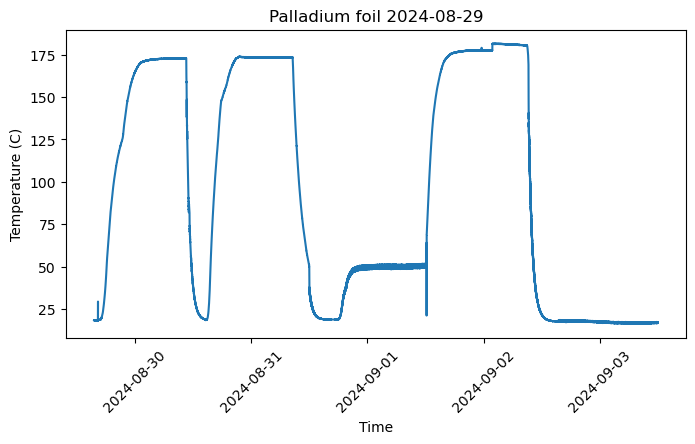

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(temperature_df['Thermocouple1Ch1'])
plt.xlabel('Time')
plt.ylabel('Temperature (C)')
plt.xticks(rotation=45)
plt.title(f"{experiment_descriptor} {temperature_df.index[0].date()}")
plt.show()

### Heating power

In [10]:
# Read the heating power data
heating_df = pd.read_csv(
    'http://nucleonics.mit.edu/call-rscript.php?filename=thermocouples_september&graphno=2f&random=58',
    parse_dates=['time'],
    date_format="ISO8601",
    index_col='time'
)

In [11]:
# When does data collection begin and end
print(f"Start: {heating_df.index[0]}, End: {heating_df.index[-1]}")

Start: 2024-08-29 15:30:01.448871, End: 2024-09-03 11:59:57.068717


In [12]:
# How many data points do we have
raw_total_heating_points = len(heating_df)
print(raw_total_heating_points)

131371


In [13]:
# What's the average time in seconds time between data points
((heating_df.index[-1] - heating_df.index[0]) / raw_total_heating_points).total_seconds()

3.192452

In [14]:
# Count problem values like NaNs
heating_df.isna().sum()

Voltage    0
Current    0
dtype: int64

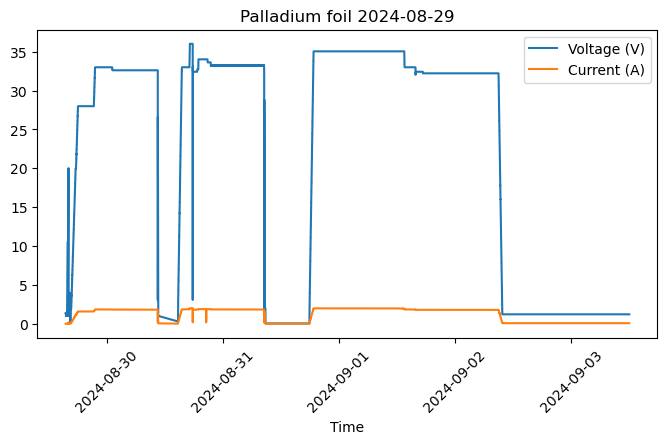

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(heating_df['Voltage'], label="Voltage (V)")
plt.plot(heating_df['Current'], label="Current (A)")
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.legend()
plt.title(f"{experiment_descriptor} {heating_df.index[0].date()}")
plt.show()

### Pressure

In [16]:
# Read the pressure data
pressure_df_1 = pd.read_csv(
    'data/20240829_162215_Pd_D_run_start.csv',
    names=['time', 'Voltage1', 'Voltage2', 'Voltage3', 'Voltage4'],
    parse_dates=['time'],
    date_format="ISO8601",
    index_col='time',
    header=None
)

pressure_df_2 = pd.read_csv(
    'data/20240830_144123_Pd_D_run_2.csv',
    names=['time', 'Voltage1', 'Voltage2', 'Voltage3', 'Voltage4'],
    parse_dates=['time'],
    date_format="ISO8601",
    index_col='time',
    header=None
)

pressure_df = pd.concat([pressure_df_1, pressure_df_2])

In [17]:
# When does data collection begin and end
print(f"Start: {pressure_df.index[0]}, End: {pressure_df.index[-1]}")

Start: 2024-08-29 16:22:22, End: 2024-09-02 15:29:08


In [18]:
# How many data points do we have
raw_total_pressure_points = len(pressure_df)
print(raw_total_pressure_points)

340301


In [19]:
# What's the average time in seconds time between data points
((pressure_df.index[-1] - pressure_df.index[0]) / raw_total_pressure_points).total_seconds()

1.006185

In [20]:
# Count problem values like NaNs
pressure_df.isna().sum()

Voltage1    0
Voltage2    0
Voltage3    0
Voltage4    0
dtype: int64

In [21]:
pressure_df.head()

,Voltage1,Voltage2,Voltage3,Voltage4
time,,,,
2024-08-29 16:22:22,2.495856,0.003905,0.003598,0.002674
2024-08-29 16:22:23,2.494625,0.004213,0.003290,0.003290
2024-08-29 16:22:24,2.489392,0.003905,0.003905,0.002674
2024-08-29 16:22:25,2.490931,0.004213,0.003290,0.003290
2024-08-29 16:22:26,2.494625,0.004521,0.003598,0.002982


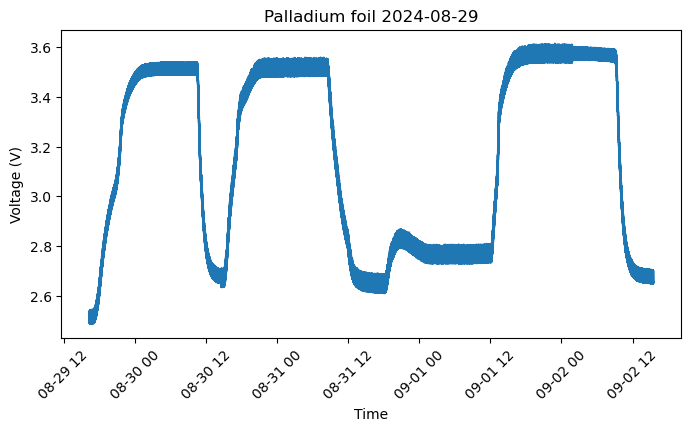

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(pressure_df['Voltage1'])
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.xticks(rotation=45)
plt.title(f"{experiment_descriptor} {pressure_df.index[0].date()}")
plt.show()

## Processing the data

### Corrupt data

There is a large spike in the temperature data about half way through 2024-09-01. We can identify the precise time be seeing where the temperature changes by more than 10C over a single measurement.

In [23]:
temperature_df[temperature_df['Thermocouple1Ch1'].diff().abs() > 10]

,Thermocouple1Ch1,Thermocouple1Ch2
time,,
2024-09-01 12:13:32.432787,21.059127,NaN
2024-09-01 12:13:33.528489,64.405032,67.295124


Looks like the time that `Thermocouple1Ch1` changed a lot was also the time when `Thermocouple1Ch2` - this suggests an error in the data logging. Let's zoom into this region to see a bit more detail.

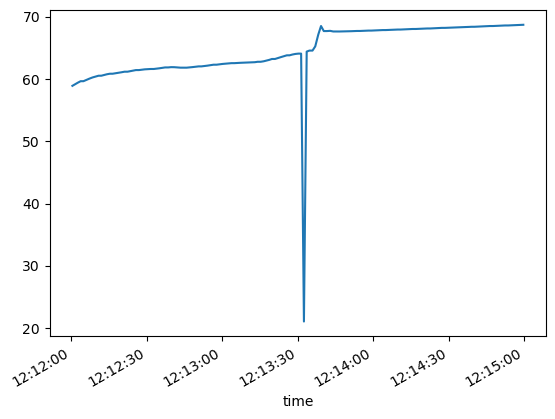

In [24]:
temperature_df['Thermocouple1Ch1']['2024-09-01 12:12':'2024-09-01 12:14'].plot();

Indeed, it looks like just a single problem point which we can safely remove.

In [25]:
# Drop corrupt temperature readings
temperature_df.drop(temperature_df[temperature_df['Thermocouple1Ch1'].diff().abs() > 10].index, inplace=True)

### Noisy data

The pressure data in particular is very noisy. Since we'll be later relying on the initial values of temperature and pressure to calculate the number of deuterium atoms in the chamber at the start of the experiment, it seems sensible to smooth out the pressure data to get a more reliable value.

Although the temperature data is not as noisy, since we need pressure and temperature to calculate the number of deuterium atoms, then it seems sensible to perform the same processing to the temperature data as well.

In [26]:
# Smoothing with a rolling mean over a 5-point window
pressure_df['Voltage1_Smoothed'] = pressure_df['Voltage1'].rolling(window=200, center=True).mean()
temperature_df['Thermocouple1Ch1_Smoothed'] = temperature_df['Thermocouple1Ch1'].rolling(window=200, center=True).mean()

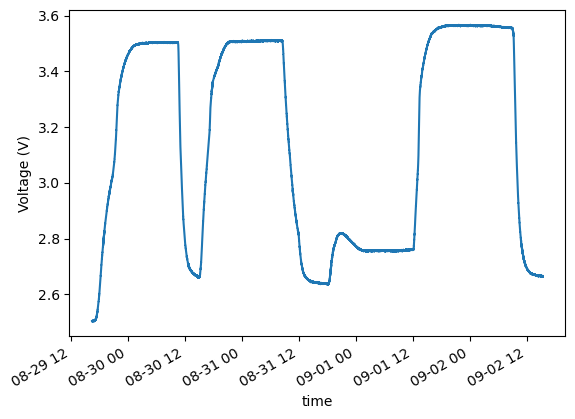

In [27]:
pressure_df['Voltage1_Smoothed'].plot().set_ylabel("Voltage (V)");

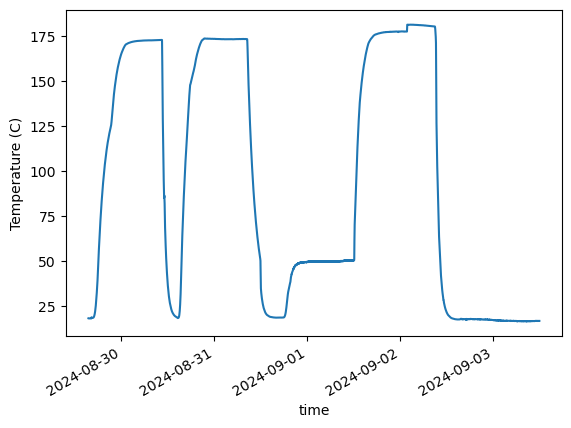

In [28]:
temperature_df['Thermocouple1Ch1_Smoothed'].plot().set_ylabel("Temperature (C)");

### Combining data

To derive physical quantities from several diagnostics, we need to have simultaneous measurements. We'll therefore need to do some interpolation of the data. This is going to involve:
1. Mapping all measurements to the nearest second
2. Selecting overlapping time intervals from the data
3. Combining the data from all diagnostics into one dataframe
4. Interpolate to fill the NaNs that result from combining the data in step 3
5. Drop any NaNs that can sometimes be generated at the edges of the time range

In [29]:
combined_df = process_data(temperature_df, pressure_df,heating_df)

In [30]:
combined_df.head()

,Thermocouple1Ch1,Thermocouple1Ch2,Thermocouple1Ch1_Smoothed,Voltage1,Voltage2,Voltage3,Voltage4,Voltage1_Smoothed,Voltage,Current
time,,,,,,,,,,
2024-08-29 16:28:54,18.479565,18.325605,18.491411,2.519249,0.004521,0.003598,0.003290,2.503671,0.150000,0.000000
2024-08-29 16:28:55,18.493355,18.335403,18.491330,2.511554,0.003905,0.003905,0.003290,2.503565,0.436667,0.016667
2024-08-29 16:28:56,18.489861,18.338173,18.491289,2.518941,0.004521,0.003290,0.002982,2.503422,0.723333,0.033333
2024-08-29 16:28:57,18.492360,18.340335,18.491251,2.494625,0.004521,0.003290,0.002982,2.503543,1.010000,0.050000
2024-08-29 16:28:58,18.494859,18.342498,18.491213,2.490008,0.004521,0.003290,0.002982,2.503582,1.013333,0.050000


### Pressure readings
The next processing step involves converting the Voltage measurement into a pressure value.

In [31]:
# Constants required to convert pressure gauge voltage into a pressure reading in bar
Resistor = 650  # resistance in Ohms
current_offset_mA = 4  # 4 mA corresponds to 0 bar
pressure_range_bar = 7  # Range is from 0 to 7 bar
current_range_mA = 16  # From 4 mA to 20 mA, so the range is 16 mA

# Calculating current in amperes
pressure_sensor_current = combined_df['Voltage1_Smoothed'] / Resistor

# Calculating pressure in bars
combined_df['pressure_bar'] = 1 + ((pressure_sensor_current * 1000 - current_offset_mA) * pressure_range_bar) / current_range_mA

### Heating power
The next step is calculating the heating power 

In [32]:
combined_df['power'] = combined_df['Voltage']*combined_df['Current']

### Inferring deuterium loading

The deuterium loading is inferred by using the ideal gas law to calculate how many deuterium molecules are present in the gas over time:

$$N_{D_2} = \frac{PV}{k_B T}$$

and associating any changes $\Delta N_{D_2}$ with deuteium entering the lattice. We can then calculate the loading based on the number of lattice atoms $N_{lattice}$:

$$N_{lattice} = 2.19\times 10^{21}$$

The loading is then:

$$2\frac{\Delta N_{D_2}}{N_{lattice}}$$

The factor 2 arrises because a single $D_2$ molecule becomes 2 deuterons once inside the lattice.

In [33]:
# Constants
V = 0.19 / 1000  # Volume of the container in m^3
kB = 1.3806503e-23  # Boltzmann constant in J/K
N_lattice = 2.19e21

In [34]:
combined_df['deuterium_molecules'] = (combined_df['pressure_bar']*1e5 * V) / (kB * (combined_df['Thermocouple1Ch1_Smoothed'] + 273.15))

In [35]:
combined_df['loading'] = 2*(combined_df.iloc[0]['deuterium_molecules'] - combined_df['deuterium_molecules']) / N_lattice

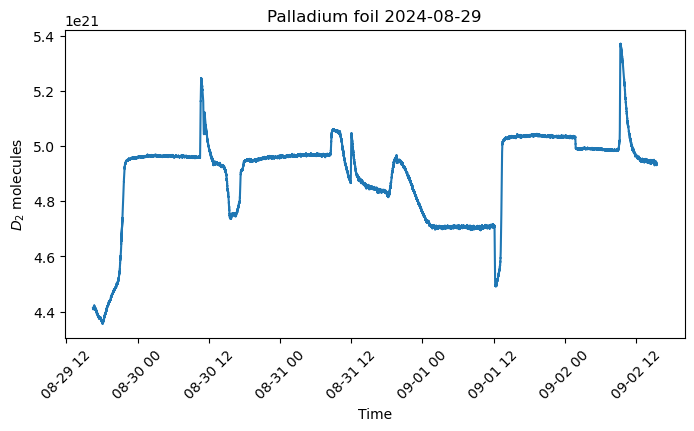

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(combined_df['deuterium_molecules'])
plt.xlabel('Time')
plt.ylabel('$D_2$ molecules')
plt.xticks(rotation=45)
plt.title(f"{experiment_descriptor} {combined_df.index[0].date()}")
plt.show()

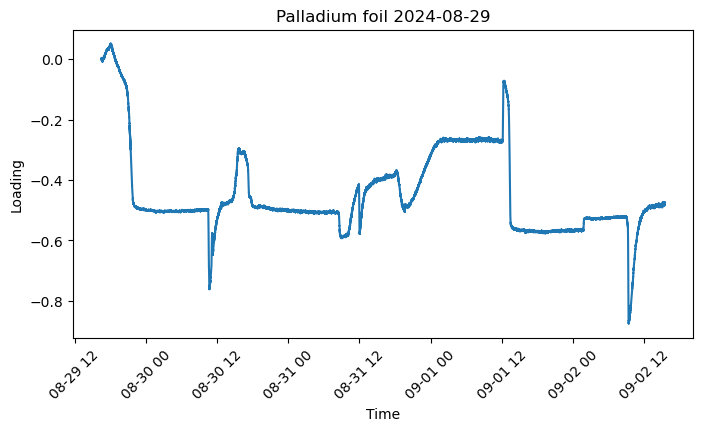

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(combined_df['loading'])
plt.xlabel('Time')
plt.ylabel('Loading')
plt.xticks(rotation=45)
plt.title(f"{experiment_descriptor} {combined_df.index[0].date()}")
plt.show()

## Visualising the data

Let's look at the whole data range first

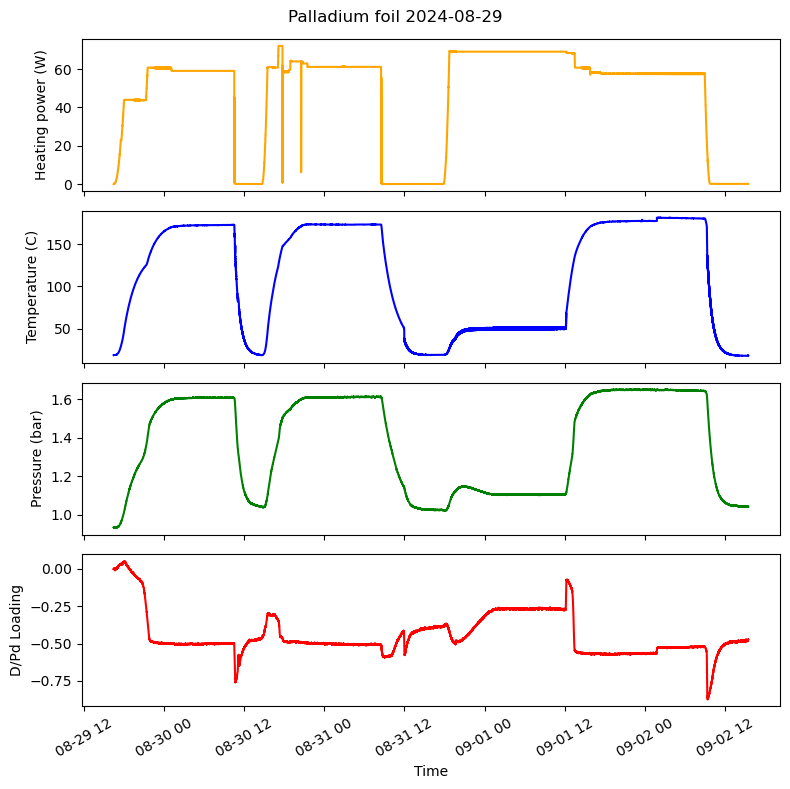

In [38]:
fig, axes = plot_panels(combined_df, ['power','Thermocouple1Ch1', 'pressure_bar', 'loading'],
                        colors=['orange','blue', 'green', 'red'])

axes[0].set_ylabel("Heating power (W)")
axes[1].set_ylabel("Temperature (C)")
axes[2].set_ylabel("Pressure (bar)")
axes[3].set_ylabel("D/Pd Loading")
fig.suptitle(f"{experiment_descriptor} {combined_df.index[0].date()}")
fig.tight_layout();